In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import copy
from pyomo import opt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.autograd as autograd
import torch.utils.data as data
import torch.utils.data.dataset as dataset

import sys
sys.path.append('..')
from utils.inn_utils import *
from utils.mdh_vis_utils import *
from utils.nonconvex_problem import NonConvexQCProblem
from utils.solver_utils import QCQPSolver

In [2]:
data = {}
for [n_var, n_qua_cons] in [[10, 10], [10,100], [10,1000],
                            [30, 10], [30,100], [30,1000],
                            [50, 10], [50,100], [50,1000]]:
    results_dir =  f'../results/inn_pgd/var_{n_var}_qua_{n_qua_cons}_ctr_convex_False'
    IPOPT_results = np.load(f'{results_dir}/IPOPT_results.npy', allow_pickle=True).item()
    INN_PGD_results = np.load(f'{results_dir}/INN-PGD_results.npy', allow_pickle=True).item()
    data[f'{n_var}_{n_qua_cons}'] = {
        'IPOPT': IPOPT_results,
        'INN-PGD': INN_PGD_results
    }

In [3]:
IPOPT_results.keys()
INN_PGD_results.keys()


dict_keys(['objectives', 'violations', 'solve_times', 'solver_status', 'feasible_solutions', 'successful_solves', 'trajectories'])

In [4]:
for i, n_var in enumerate([10, 30, 50]):
    solver_time_list = []
    inn_pgd_time_list = []
    for j, n_qua_cons in enumerate([10, 100, 1000]):
        solver_time_mean = (data[f'{n_var}_{n_qua_cons}']['IPOPT']['objectives'])[0]
        inn_pgd_time_mean = (data[f'{n_var}_{n_qua_cons}']['INN-PGD']['objectives'])[0]
        print(
            f"n_var: {n_var:<6} | "
            f"n_qua_cons: {n_qua_cons:<6} | "
            f"IPOPT: {solver_time_mean:>8.3f} s | "
            f"INN-PGD: {inn_pgd_time_mean:>8.3f} s"
        )

n_var: 10     | n_qua_cons: 10     | IPOPT:   -1.481 s | INN-PGD:   -1.446 s
n_var: 10     | n_qua_cons: 100    | IPOPT:   -0.941 s | INN-PGD:   -0.927 s
n_var: 10     | n_qua_cons: 1000   | IPOPT:   -1.474 s | INN-PGD:   -1.195 s
n_var: 30     | n_qua_cons: 10     | IPOPT:   -0.802 s | INN-PGD:   -0.777 s
n_var: 30     | n_qua_cons: 100    | IPOPT:   -0.626 s | INN-PGD:   -0.614 s
n_var: 30     | n_qua_cons: 1000   | IPOPT:   -0.790 s | INN-PGD:   -0.779 s
n_var: 50     | n_qua_cons: 10     | IPOPT:   -0.665 s | INN-PGD:   -0.634 s
n_var: 50     | n_qua_cons: 100    | IPOPT:   -0.635 s | INN-PGD:   -0.620 s
n_var: 50     | n_qua_cons: 1000   | IPOPT:   -0.602 s | INN-PGD:   -0.590 s


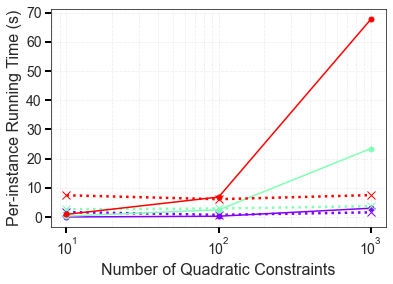

In [6]:
import seaborn as sns
sns.set_style("white")
from matplotlib import cm
from matplotlib.colors import Normalize

n_models = 3
cmap = cm.get_cmap('rainbow')  # or 'plasma', 'coolwarm', etc.
norm = Normalize(vmin=0, vmax=n_models-1)
fig = plt.figure(figsize=[6, 4])
for i, n_var in enumerate([10, 30, 50]):
    solver_time_list = []
    inn_pgd_time_list = []
    for j, n_qua_cons in enumerate([10, 100, 1000]):
        solver_time_mean = np.mean(data[f'{n_var}_{n_qua_cons}']['IPOPT']['solve_times'])
        inn_pgd_time_mean = np.mean(data[f'{n_var}_{n_qua_cons}']['INN-PGD']['solve_times'])
        solver_time_list.append(solver_time_mean)
        inn_pgd_time_list.append(inn_pgd_time_mean)
        
    plt.plot([10, 100, 1000], solver_time_list, linestyle='-', marker='o', markersize=5, color=cmap(norm(i)))
    plt.plot([10, 100, 1000], inn_pgd_time_list, linestyle=':', marker='x', markersize=8, color=cmap(norm(i)),linewidth=2.5)

plt.xscale('log')
plt.xlabel('Number of Quadratic Constraints', fontsize=16)
plt.ylabel('Per-instance Running Time (s)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tick_params(
axis='both',        # 'x', 'y', 或 'both'
which='major',       # 'major', 'minor', 或 'both'
direction='out',     # 刻度线方向: 'in', 'out', 或 'inout'
length=6,           # 刻度线长度
width=2,            # 刻度线宽度
color='black',      # 刻度线颜色
# top=True,           # 顶部显示刻度线
# right=True,         # 右侧显示刻度线
bottom=True,        # 底部显示刻度线
left=True           # 左侧显示刻度线
)

plt.savefig('scalability_qcqp.pdf', dpi=300, bbox_inches='tight')


/Users/liangenming/opt/anaconda3/envs/lem_app/lib/python3.7/site-packages/ipykernel_launcher.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  if __name__ == '__main__':
/Users/liangenming/opt/anaconda3/envs/lem_app/lib/python3.7/site-packages/ipykernel_launcher.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 


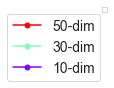

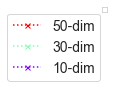

In [103]:
plt.figure(figsize=[0.1, 0.1])
plt.xticks([])
plt.yticks([])
# plt.plot([], [], label = r'IPOPT',linewidth=0)
plt.plot([], [], label='50-dim', linestyle='-', marker='o', markersize=5, color=cmap(norm(2)))
plt.plot([], [], label='30-dim', linestyle='-', marker='o', markersize=5, color=cmap(norm(1)))
plt.plot([], [], label='10-dim', linestyle='-', marker='o', markersize=5, color=cmap(norm(0)))
plt.legend(fontsize=14, ncol=1)
plt.tight_layout()
plt.savefig('legend_ipopt.pdf', dpi=300, bbox_inches='tight')

plt.figure(figsize=[0.1, 0.1])
plt.xticks([])
plt.yticks([])
# # plt.plot([], [], label=r'Hom-PGD$^+$',linewidth=0)
plt.plot([], [], label='50-dim', linestyle=':', marker='x', markersize=5, color=cmap(norm(2)))
plt.plot([], [], label='30-dim', linestyle=':', marker='x', markersize=5, color=cmap(norm(1)))
plt.plot([], [], label='10-dim', linestyle=':', marker='x', markersize=5, color=cmap(norm(0)))


plt.legend(fontsize=14, ncol=1)
plt.tight_layout()
plt.savefig('legend_hompgd.pdf', dpi=300, bbox_inches='tight')


In [31]:
problem_args = {
        'seed': 2030,
        'constraint_convexity': False,
        'objective_convexity': True,
        'obj': 'quad',
        'n_var': 2,
        'n_qua_cons': 2,
        'n_linear_cons': 0,
        'nonconvex_ratio': 1,
        'x_lower': -5.0,
        'x_upper': 5.0,
        'R': 5,
        }
# Create problem generator
data = NonConvexQCProblem(problem_args)
save_dir = f"../results/sensitivity_analysis/{5}_layer"
mdh_mapping_path = os.path.join(save_dir, f"mdh_mapping_made.pth")
model = torch.load(mdh_mapping_path, map_location=DEVICE, weights_only=False)

  Feasible transformed points: 4939/5000 (98.8%)
  Feasible transformed points: 4834/5000 (96.7%)
  Feasible transformed points: 4944/5000 (98.9%)

MDH mapping visualization saved to: ../results/sensitivity_analysis/5_layer/mdh_mapping_visualization_mdh_mapping_visualization.png


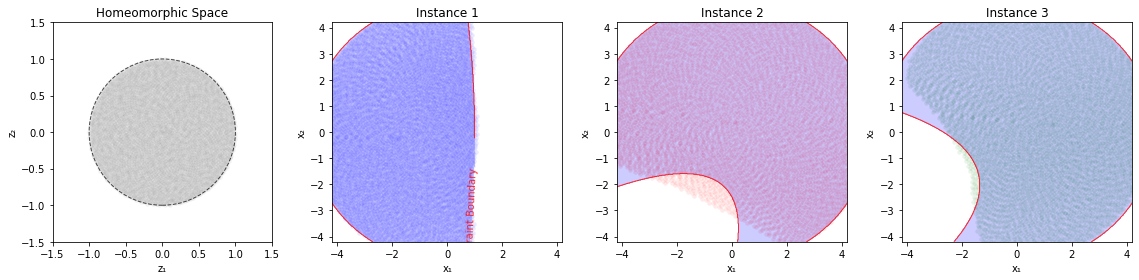

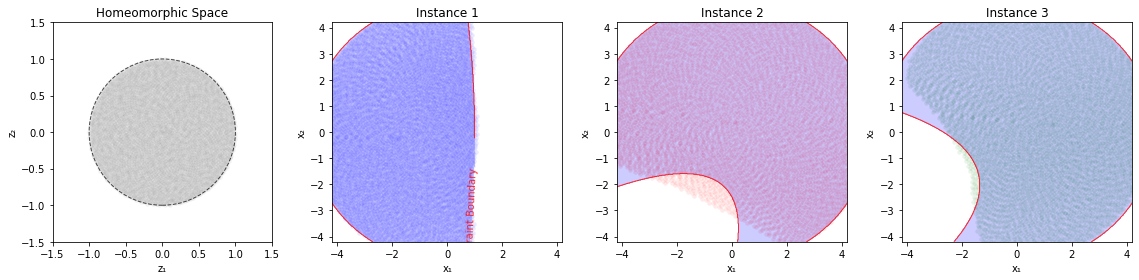

In [32]:
visualize_mdh_mapping_transformation(model, data, 
                                    save_path=os.path.join(save_dir, 'mdh_mapping_visualization.png'),
                                    n_samples=5000, seed=2020)

dict_keys(['volume_list', 'penalty_list', 'dist_list', 'trans_list'])

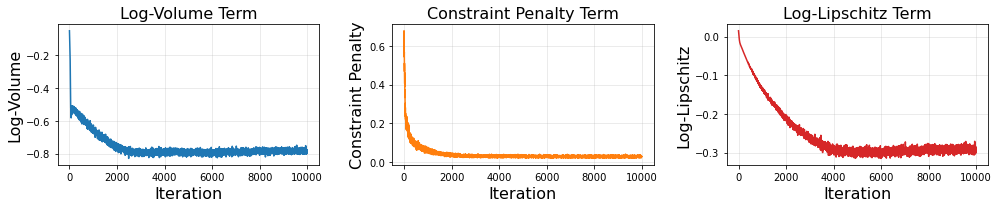

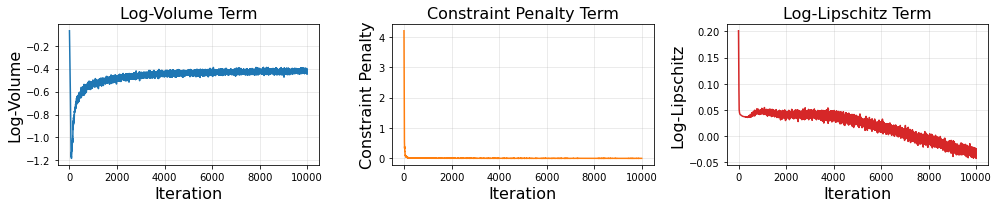

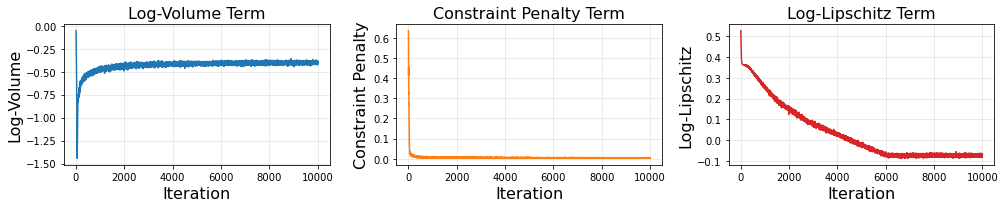

In [39]:
for num_layers in [1, 3, 5]:
    save_dir = f"results/sensitivity_analysis/{num_layers}_layer"
    inn_training_records = np.load(f"{save_dir}/training_record.npy", allow_pickle=True).item()   
    inn_training_records.keys()

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 3))

    # Plot training metrics
    ax1.plot(inn_training_records['volume_list'], color='C0')
    ax1.set_title('Log-Volume Term', fontsize=16)
    ax1.set_xlabel('Iteration', fontsize=16)
    ax1.set_ylabel('Log-Volume', fontsize=16)
    ax1.grid(True, alpha=0.3)

    ax2.plot(inn_training_records['penalty_list'], color='C1')
    ax2.set_title('Constraint Penalty Term', fontsize=16)
    ax2.set_xlabel('Iteration', fontsize=16)
    ax2.set_ylabel('Constraint Penalty', fontsize=16)
    ax2.grid(True, alpha=0.3)

    ax3.plot(inn_training_records['dist_list'], color='C3')
    ax3.set_title('Log-Lipschitz Term', fontsize=16)
    ax3.set_xlabel('Iteration', fontsize=16)
    ax3.set_ylabel('Log-Lipschitz', fontsize=16)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/{num_layers}_layer_inn_training_metrics.png", dpi=300, bbox_inches='tight')

In [77]:
color_list =  [ '#0072B2', '#F5B378', '#8EC6C2',  # pink/magenta
        '#9467BD',  # purple (replacing the yellow)
        '#E83947',  # greenz
        '#000000',  # black
    ]
line_style_list = ['-', '--', '-.', '-..', '-']

In [97]:
max_iter = 150
for instance_idx in range(10):
    fig = plt.figure(figsize=(5, 4))
    for i,num_layers in enumerate([1, 3, 5]):
        save_dir = f"results/sensitivity_analysis/{num_layers}_layer"
        inn_pgd = np.load(f"{save_dir}/INN-PGD_results.npy", allow_pickle=True).item()
        solver_results = np.load(f"{save_dir}/IPOPT_results.npy", allow_pickle=True).item()
        iteration = range(max_iter+1)
        # cum_time = np.cumsum([0]+list(inn_pgd['trajectories'][instance_idx]['per_iter_time']))
        obj = inn_pgd['trajectories'][instance_idx]['obj_trajectory']
        opt = solver_results['objectives'][instance_idx]
        gap = np.abs(obj - opt)/np.abs(opt)
        plt.plot(iteration, gap[:max_iter+1], label=f'{num_layers}-layer INN', color=color_list[i], linestyle=line_style_list[i])
    plt.xlabel('Iteration', fontsize=16)
    plt.ylabel('Optimal Gap', fontsize=16)
    plt.xscale('log')
    # plt.yscale('log')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    plt.savefig(f"results/sensitivity_analysis/{instance_idx}_INN-PGD_objective_vs_iteration.png", dpi=300, bbox_inches='tight')
    plt.close()

# for instance_idx in range(10):
#     fig = plt.figure(figsize=(5, 4))
#     for i,num_layers in enumerate([1, 3, 5]):
#         save_dir = f"results/sensitivity_analysis/{num_layers}_layer"
#         inn_pgd = np.load(f"{save_dir}/INN-PGD_results.npy", allow_pickle=True).item()
#         solver_results = np.load(f"{save_dir}/IPOPT_results.npy", allow_pickle=True).item()
#         iteration = range(max_iter+1)
#         cum_time = np.cumsum([0]+list(inn_pgd['trajectories'][instance_idx]['per_iter_time']))
#         obj = inn_pgd['trajectories'][instance_idx]['obj_trajectory']
#         opt = solver_results['objectives'][instance_idx]
#         gap = np.abs(obj - opt)/np.abs(opt)
#         plt.plot(cum_time[:max_iter+1], gap[:max_iter+1], label=f'{num_layers}-layer INN', color=color_list[i], linestyle=line_style_list[i])
#     plt.xlabel('Running Time (s)', fontsize=16)
#     plt.ylabel('Optimal Gap', fontsize=16)
#     plt.xscale('log')
#     plt.yscale('log')
#     plt.legend(fontsize=16)
#     plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
#     plt.savefig(f"results/sensitivity_analysis/{instance_idx}_INN-PGD_objective_vs_running_time.png", dpi=300, bbox_inches='tight')
#     plt.close()

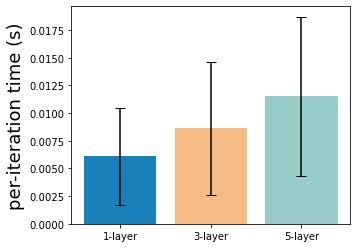

In [88]:
iter_time_mean = []
iter_time_std = []
for instance_idx in range(1):
    for num_layers in [1,3,5]:
        save_dir = f"results/sensitivity_analysis/{num_layers}_layer"
        inn_pgd = np.load(f"{save_dir}/INN-PGD_results.npy", allow_pickle=True).item()
        iter_time = inn_pgd['trajectories'][instance_idx]['per_iter_time']
        iter_time_mean.append(np.mean(iter_time))
        iter_time_std.append(np.std(iter_time))

fig = plt.figure(figsize=(5, 4))
plt.bar(['1-layer', '3-layer', '5-layer'], iter_time_mean,
        color=color_list,
        alpha=0.9, yerr=iter_time_std, capsize=5)
plt.ylabel('per-iteration time (s)', fontsize=18)
plt.savefig('per_iter_time.png_inn_layer_comparison.png', dpi=300, bbox_inches='tight')

In [69]:
solver_results = np.load(f"{save_dir}/IPOPT_results.npy", allow_pickle=True).item()
solver_results['objectives'][0]

-2.69210206519241

In [ ]:
max_iter = 150
for instance_idx in range(10):
    fig = plt.figure(figsize=(5, 4))
    for i,eps in enumerate([1e-5, 1e-3, 1e-1]):
        save_dir = f"results/sensitivity_analysis/feasibility_eps_{eps}"
        inn_pgd = np.load(f"{save_dir}/INN-PGD_results.npy", allow_pickle=True).item()
        solver_results = np.load(f"{save_dir}/IPOPT_results.npy", allow_pickle=True).item()
        iteration = range(max_iter+1)
        # cum_time = np.cumsum([0]+list(inn_pgd['trajectories'][instance_idx]['per_iter_time']))
        obj = inn_pgd['trajectories'][instance_idx]['obj_trajectory']
        opt = solver_results['objectives'][instance_idx]
        gap = np.abs(obj - opt)/np.abs(opt)
        plt.plot(iteration, gap[:max_iter+1], label=f'bis. eps={eps}', color=color_list[i], linestyle=line_style_list[i])
    plt.xlabel('Iteration', fontsize=16)
    plt.ylabel('Optimal Gap', fontsize=16)
    plt.xscale('log')
    plt.yscale('log')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    plt.savefig(f"results/sensitivity_analysis/bis_eps_{instance_idx}_INN-PGD_objective_vs_iteration.png", dpi=300, bbox_inches='tight')
    plt.close()



In [102]:
max_iter = 150
for instance_idx in range(10):
    fig = plt.figure(figsize=(5, 4))
    for i,eps in enumerate([1e-5, 1e-3, 1e-1]):
        save_dir = f"results/sensitivity_analysis/feasibility_eps_{eps}"
        inn_pgd = np.load(f"{save_dir}/INN-PGD_results.npy", allow_pickle=True).item()
        solver_results = np.load(f"{save_dir}/IPOPT_results.npy", allow_pickle=True).item()
        iteration = range(max_iter+1)
        # cum_time = np.cumsum([0]+list(inn_pgd['trajectories'][instance_idx]['per_iter_time']))
        cons = inn_pgd['trajectories'][instance_idx]['cons_trajectory']
        # opt = solver_results['violations'][instance_idx]
        gap = np.abs(obj - opt)/np.abs(opt)
        plt.plot(iteration, cons[:max_iter+1], label=f'bis. eps={eps}', color=color_list[i], linestyle=line_style_list[i])
    plt.xlabel('Iteration', fontsize=16)
    plt.ylabel('Violation', fontsize=16)
    plt.xscale('log')
    plt.yscale('log')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    plt.savefig(f"results/sensitivity_analysis/bis_eps_{instance_idx}_INN-PGD_violation_vs_iteration.png", dpi=300, bbox_inches='tight')
    plt.close()

/Users/liangenming/opt/anaconda3/envs/lem_app/lib/python3.7/site-packages/ipykernel_launcher.py:17: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
/Users/liangenming/opt/anaconda3/envs/lem_app/lib/python3.7/site-packages/ipykernel_launcher.py:17: UserWarning: Data has no positive values, and therefore cannot be log-scaled.


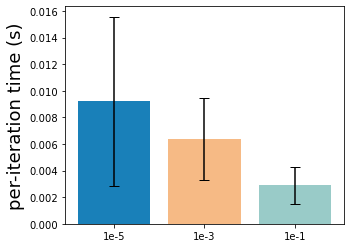

In [91]:
iter_time_mean = []
iter_time_std = []
for instance_idx in range(1):
    for eps in [1e-5, 1e-3, 1e-1]:
        save_dir = f"results/sensitivity_analysis/feasibility_eps_{eps}"
        inn_pgd = np.load(f"{save_dir}/INN-PGD_results.npy", allow_pickle=True).item()
        iter_time = inn_pgd['trajectories'][instance_idx]['per_iter_time']
        iter_time_mean.append(np.mean(iter_time))
        iter_time_std.append(np.std(iter_time))

fig = plt.figure(figsize=(5, 4))
plt.bar(['1e-5', '1e-3', '1e-1'], iter_time_mean,
        color=color_list,
        alpha=0.9, yerr=iter_time_std, capsize=5)
plt.ylabel('per-iteration time (s)', fontsize=18)
plt.savefig('per_iter_time.png_bis_comparison.png', dpi=300, bbox_inches='tight')

In [ ]:
max_iter = 150
for instance_idx in range(10):
    fig = plt.figure(figsize=(5, 4))
    for i,optimizer in enumerate(['gd', 'adam']):
        save_dir = f"results/sensitivity_analysis/opt_{optimizer}"
        inn_pgd = np.load(f"{save_dir}/INN-PGD_results.npy", allow_pickle=True).item()
        solver_results = np.load(f"{save_dir}/IPOPT_results.npy", allow_pickle=True).item()
        iteration = range(max_iter+1)
        # cum_time = np.cumsum([0]+list(inn_pgd['trajectories'][instance_idx]['per_iter_time']))
        obj = inn_pgd['trajectories'][instance_idx]['obj_trajectory']
        opt = solver_results['objectives'][instance_idx]
        gap = np.abs(obj - opt)/np.abs(opt)
        plt.plot(iteration, gap[:max_iter+1], label=f'{optimizer}', color=color_list[i], linestyle=line_style_list[i])
    plt.xlabel('Iteration', fontsize=16)
    plt.ylabel('Optimal Gap', fontsize=16)
    plt.xscale('log')
    plt.yscale('log')
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    plt.savefig(f"results/sensitivity_analysis/opt_{instance_idx}_INN-PGD_objective_vs_iteration.png", dpi=300, bbox_inches='tight')
    plt.close()

